<a href="https://colab.research.google.com/github/Mangesh0309/BE-SPPU/blob/main/Assignment1DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [17]:
import numpy as mp
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [18]:
boston = fetch_openml(name='boston', version=1, as_frame=True)

boston.data.shape

(506, 13)

In [19]:
boston.feature_names

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT']

In [20]:
boston.data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [21]:
# Input data
X = boston.data

# Output Data
y = boston.target

# convert target to numeric
y = y.astype(float)

print("Feature shape:", X.shape)
print("target shape:", y.shape)

Feature shape: (506, 13)
target shape: (506,)


Loading train and test data


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
X_train[:5]

array([[ 1.28770177, -0.50032012,  1.03323679, -0.27808871,  0.48925206,
        -1.42806858,  1.02801516, -0.80217296,  1.70689143,  1.57843444,
         0.84534281, -0.07433689,  1.75350503],
       [-0.33638447, -0.50032012, -0.41315956, -0.27808871, -0.15723342,
        -0.68008655, -0.43119908,  0.32434893, -0.62435988, -0.58464788,
         1.20474139,  0.4301838 , -0.5614742 ],
       [-0.40325332,  1.01327135, -0.71521823, -0.27808871, -1.00872286,
        -0.40206304, -1.6185989 ,  1.3306972 , -0.97404758, -0.60272378,
        -0.63717631,  0.06529747, -0.65159505],
       [ 0.38822983, -0.50032012,  1.03323679, -0.27808871,  0.48925206,
        -0.30045039,  0.59168149, -0.8392398 ,  1.70689143,  1.57843444,
         0.84534281, -3.86819251,  1.52538664],
       [-0.32528234, -0.50032012, -0.41315956, -0.27808871, -0.15723342,
        -0.83109424,  0.03374663, -0.00549428, -0.62435988, -0.58464788,
         1.20474139,  0.3791194 , -0.16578736]])

Creating the model

In [24]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu',),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)     # Output layer for regression

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compiling the model

In [25]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

Training the model

In [26]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose= 1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 599.5397 - mae: 22.5852 - val_loss: 523.0446 - val_mae: 21.3482
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 549.9852 - mae: 21.5436 - val_loss: 464.4962 - val_mae: 20.0003
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 458.1986 - mae: 19.3920 - val_loss: 344.7672 - val_mae: 16.8754
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 288.7303 - mae: 14.6107 - val_loss: 158.9747 - val_mae: 10.4556
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 116.1384 - mae: 8.4378 - val_loss: 57.8917 - val_mae: 5.4664
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 67.0696 - mae: 6.3464 - val_loss: 36.7672 - val_mae: 4.2065
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 40.4778 - mae: 4.8054 - val_loss: 30.1383 - val_mae: 3.7150
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30.3109 - mae: 4.0763 - val_loss: 28.2039 - val_mae: 3.6421
Epoch 9/100
21/21 ━━━━━━━━━━━━

### Making Predictions
To make predictions with the trained model, you need to provide new input data. This data should be preprocessed in the same way your training data was (i.e., scaled using the `scaler` object). Below is an example using one sample from the `X_test` dataset.

In [27]:
# Take one sample from X_test to demonstrate prediction
sample_input = X_test[0:1]

# Make a prediction
prediction = model.predict(sample_input)

print(f"Sample Input (scaled features):\n{sample_input}")
print(f"Predicted Output: {prediction[0][0]:.2f}")
print(f"Actual Output (for comparison): {y_test.iloc[0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Sample Input (scaled features):
[[-0.39680933 -0.50032012 -1.00711147 -0.27808871 -0.39541229  0.14128239
   0.55591643 -0.54585271 -0.50779731 -0.65092617 -0.77195078  0.42887165
  -0.48121032]]
Predicted Output: 27.41
Actual Output (for comparison): 23.60


In [28]:
loss, mae = model.evaluate(X_test, y_test)

print("Test loss (MSE): ", loss)
print("Test MAE: ", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 14.5779 - mae: 2.4168
Test loss (MSE):  14.577863693237305
Test MAE:  2.4168431758880615


In [29]:
y_pred = model.predict(X_test)

# Compare actual and predicted
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.flatten()
})

comparison.head()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


,Actual,Predicted
0,23.6,27.410543
1,32.4,35.591686
2,13.6,16.775347
3,22.8,23.524038
4,16.1,16.414629


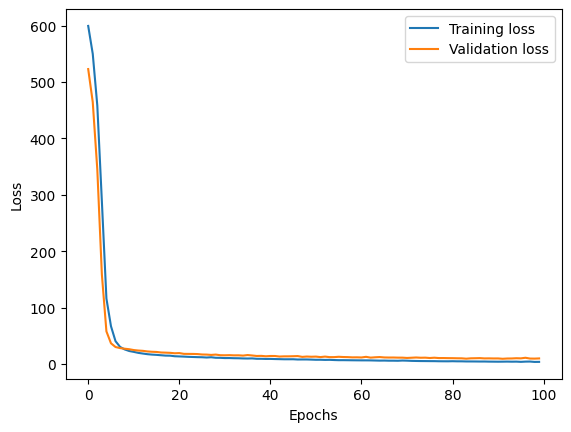

In [30]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

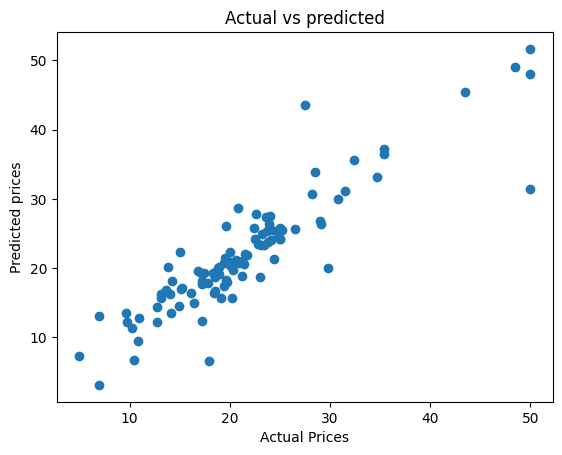

In [34]:
plt.scatter(y_test, y_pred, colorizer='red')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted prices")
plt.title("Actual vs predicted")
plt.show()
